PRÁCTICA MACHINE LEARNING: Predecir el mercado de valores

 ¡Hola y bienvenido a la Práctica de Machine Learning más difícil del mundo!

Este notebook está diseñado para ayudarte a comenzar con la práctica.

En este cuaderno vamos a:

- Descargar y explorar el conjunto de datos
- Entrenar y evaluar este primer modelo de aprendizaje automático
- Implementar el modelo para comenzar a realizar predicciones

In [1]:
# Instala dependencias
# !pip install -q --upgrade numerapi pandas pyarrow matplotlib lightgbm scikit-learn scipy cloudpickle==3.1.1
# !pip install -q --no-deps numerai-tools

# Gráficas Inline
%matplotlib inline

## DATASET

A alto nivel, trabajaremos con un conjunto de datos tabulares que describe el mercado de valores a lo largo del tiempo.

Cada fila representa una acción en un momento específico, donde "id" es la identificación de la acción y "era" es la fecha. 

Las características describen los atributos de la acción (por ejemplo, el ratio Price/Earning) conocidos en una fecha dada, y "target" es una medida de rendimientos a 20 días.

El conjunto de datos está ofuscado, lo que significa que los identificadores de acciones (stocks) subyacentes, los nombres de las características y las definiciones de objetivos son anónimos. Esto hace que podamos trabajar con estos datos de forma gratuita y que puedan modelarse sin ningún conocimiento (¡o sesgo!) del dominio financiero.

Descargamos los datos históricos de entrenamiento y echamos un vistazo de cerca.

In [7]:
# Inicializa NumerAPI - el cliente oficial de Python para acceder al API de nuestro conjunto de datos.
from numerapi import NumerAPI
napi = NumerAPI()

# Set data version to one of the latest datasets
DATA_VERSION = "v5.0"

# Imprime todos los ficheros del conjunto de datos disponibles para descargar los más recientes.
[f for f in napi.list_datasets() if f.startswith(DATA_VERSION)]

['v5.0/features.json',
 'v5.0/live.parquet',
 'v5.0/live_benchmark_models.parquet',
 'v5.0/live_example_preds.csv',
 'v5.0/live_example_preds.parquet',
 'v5.0/meta_model.parquet',
 'v5.0/train.parquet',
 'v5.0/train_benchmark_models.parquet',
 'v5.0/validation.parquet',
 'v5.0/validation_benchmark_models.parquet',
 'v5.0/validation_example_preds.csv',
 'v5.0/validation_example_preds.parquet']

In [8]:
import pandas as pd
import json

# Descarga los datos de entrenamiento y los metadatos de las características
# Esto tomará unos pocos minutos 🍵
#napi.download_dataset(f"{DATA_VERSION}/train.parquet");
#napi.download_dataset(f"{DATA_VERSION}/features.json");

# Carga solo el conjunto de features "medium" para reducir el uso de memoria y acelerar el entrenamiento del modelo 
# O bien, utiliza el conjunto de features "all" para usar todas las características
# En este ejemplo descargaremos solo el "small"
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]
for feature_set in ["small", "medium", "all"]:
  print(feature_set, len(feature_sets[feature_set]))

feature_set = feature_sets["small"]
#feature_cols = feature_metadata["feature_sets"]["small"]
#train = pd.read_parquet(f"{DATA_VERSION}/train.parquet", columns=["era"] + feature_cols + ["target"])
train = pd.read_parquet(
    f"{DATA_VERSION}/train.parquet",
    columns=["era", "target"] + feature_set
)

# Reduce la muestra, tomando cada cuatro eras, para reducir el uso de memoria y acelerar el entrenamiento del modelo (toma las eras 0001, 0005, 0009, ...)
# Comenta la línea a continuación para utilizar todos los datos.
train = train[train["era"].isin(train["era"].unique()[::4])]
train

small 42
medium 705
all 2376


,era,target,feature_antistrophic_striate_conscriptionist,feature_bicameral_showery_wallaba,feature_bridal_fingered_pensioner,feature_collectivist_flaxen_gueux,feature_concurring_fabled_adapter,feature_crosscut_whilom_ataxy,feature_departmental_inimitable_sentencer,feature_dialectal_homely_cambodia,...,feature_tridactyl_immoral_snorting,feature_trimeter_soggy_greatest,feature_unanalyzable_excusable_whirlwind,feature_unbreakable_constraining_hegelianism,feature_unformed_bent_smatch,feature_unministerial_unextenuated_teleostean,feature_unmodish_zymogenic_rousing,feature_unsystematized_subcardinal_malaysia,feature_willful_sere_chronobiology,feature_zoological_peristomial_scute
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,0.25,2,2,2,2,2,0,1,2,...,4,1,1,3,0,2,2,3,3,2
n003bba8a98662e4,0001,0.25,2,2,2,2,2,1,4,2,...,4,2,0,0,0,2,2,4,4,2
n003bee128c2fcfc,0001,0.75,2,2,2,2,2,2,2,2,...,3,1,1,0,1,2,2,0,3,2
n0048ac83aff7194,0001,0.25,2,2,2,2,2,1,4,2,...,1,3,4,1,2,2,2,2,0,2
n0055a2401ba6480,0001,0.25,2,2,2,2,2,0,0,2,...,1,0,1,0,0,2,2,1,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
nffc2d5e4b79a7ae,0573,0.00,1,2,1,0,3,2,1,1,...,2,2,1,2,3,3,3,2,2,1
nffc9844c1c7a6a9,0573,0.25,2,1,2,1,4,2,2,4,...,4,0,0,3,1,3,3,2,3,2
nffd79773f4109bb,0573,0.50,3,4,0,3,4,1,0,1,...,3,0,0,0,1,1,4,0,1,2


ERAS:

Como se mencionó anteriormente, cada "era" corresponde a una fecha diferente. Cada "era" tiene exactamente una semana de diferencia.

Es útil pensar en filas de acciones dentro de la misma "era" como un solo ejemplo. A lo largo de este notebook hablaremos de cosas "por era". Por ejemplo, el número de filas por "era" representa el conjunto de acciones (stocks) dentro de las posibilidades de inversión de algún fondo en esa fecha.

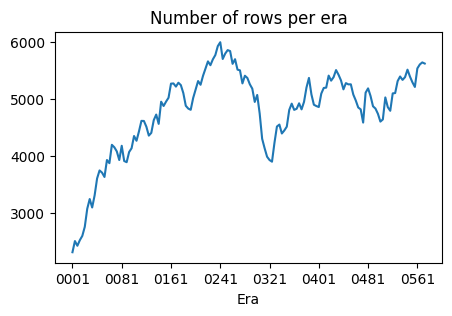

In [9]:
# Muestra el número de filas por era
train.groupby("era").size().plot(title="Number of rows per era", figsize=(5, 3), xlabel="Era");

FEATURES:

Como se mencionó anteriormente, las características son atributos cuantitativos de cada acción: fundamentos como la relación P/E (precio/beneficio), señales técnicas como el RSI, datos de mercado como el interés a corto, datos secundarios como las calificaciones de los analistas y mucho más.

La definición subyacente de cada característica no es importante, solo debes saber que se han incluido estas características en el conjunto de datos porque se cree que pueden ser relevantes para predecir el "target".

In [10]:
# Número de características
len(feature_set)

42

Los valores de las características se agrupan en 5 contenedores iguales: 0, 1, 2, 3, 4. Esta fuerte estandarización de los valores de las características tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

Si faltan datos de una característica particular para esa era (más común en las primeras eras), todos los valores se establecen en 2.


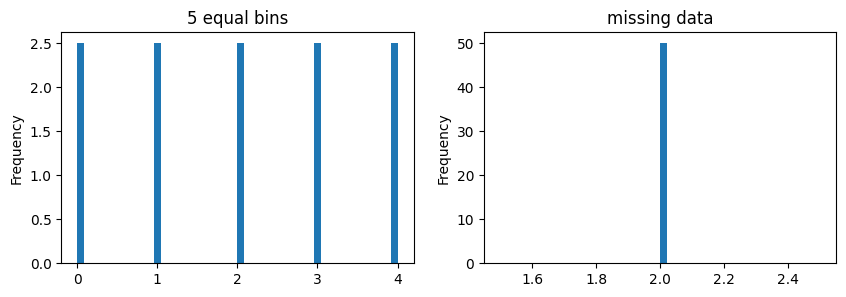

In [11]:
# Compara la distribución de una característica particular (feature_cols[-1]) entre dos períodos diferentes (first_era y last_era) en el conjunto de datos train.
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
first_era = train[train["era"] == train["era"].unique()[0]]
last_era = train[train["era"] == train["era"].unique()[-1]]
last_era[feature_set[-1]].plot(kind="hist", title="5 equal bins", density=True, bins=50, ax=ax1);
first_era[feature_set[-1]].plot(kind="hist", title="missing data", density=True, bins=50, ax=ax2);

TARGET:

El "target" es una medida de los rendimientos del mercado de valores a 20 días. Específicamente, es una medida de rendimientos "específicos de acciones" que no se "explican" por tendencias más amplias en el mercado, país, sector o "factores" bien conocidos.

Los valores del "target" se agrupan en 5 contenedores desiguales: 0, 0,25, 0,5, 0,75, 1,0. Nuevamente, esta fuerte estandarización de los valores de target tiene como objetivo evitar el overfitting, ya que los valores subyacentes son extremadamente ruidosos.

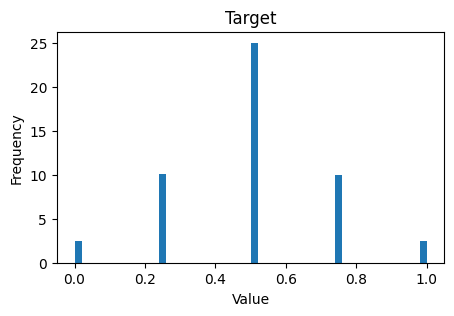

In [12]:
# Histograma (densidad) de "target"
train["target"].plot(kind="hist", title="Target", figsize=(5, 3), xlabel="Value", density=True, bins=50);

In [13]:
null_check = train.isnull().values.any()

print(f"Are there any null values in the dataset: {null_check}")

Are there any null values in the dataset: False


Se puede observar que no hay ningun valor nulo en el dataset, esto es debido a que, como se menciono anteriormente, si hubiera algun nulo, este ya fue reemplazado por el valor 2, por lo que no es necesario ningun tipo de preprocesamiento para manejar valores nulos.

Reduccion de filas: 

Si se han eliminado filas del dataset, ya que solo se esta seleccionando datos de cada cuatro eras. La razon de esto es para poder probar cosas de forma mucho mas rapida y eficiente, como feature selection o PCA. Mas adelante, cuando por ejemplo ya se terminen los experimentos y se tenga un modelo final, se podria usar el dataset completo.

Aplicacion de estandarizacion, escalado o normalizacion:

No he aplicado ningun tipo de preprocesamiento de ese tipo, la razon es que los datos ya estan escalados, como se menciono anteriormente, todas las features ya han sido preprocesadas para tener un valor de 0, 1, 2, 3 o 4, por lo que ya tienen la misma escala y rango, por lo que no veo necesario hacer un escalado adicional.

Entrenamiento del modelo base:

Eres libre de utilizar cualquier algoritmo visto en clase. Pero, en este ejemplo, usaremos LGBMRegressor, basado en árboles de decisión para predecir variables continuas. Es una opción popular para las predicciones de este tipo.

In [14]:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html 
import lightgbm as lgb #En mi mac, tuve que instalar libomp: "brew install libomp"

# https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html
model = lgb.LGBMRegressor(
  n_estimators=2000,
  learning_rate=0.01,
  max_depth=5,
  num_leaves=2**5-1,
  colsample_bytree=0.1,
  random_state=42,
  n_jobs=-1
)

# This will take a few minutes 🍵
model.fit(
  train[feature_set],
  train["target"]
);

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003087 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 688184, number of used features: 42
[LightGBM] [Info] Start training from score 0.500008


Ahora hagamos algunas predicciones con los datos de validación para evaluar el rendimiento de nuestro modelo.

In [15]:
# Descarga validation data 
# Esto tomará unos pocos minutos 🍵
#napi.download_dataset(f"{DATA_VERSION}/validation.parquet");

# Carga el validation data, filtrando por data_type == "validation"
validation = pd.read_parquet(
    f"{DATA_VERSION}/validation.parquet",
    columns=["era", "data_type", "target"] + feature_set
)
validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

# Reduce la muestra a cada cuarta era para reducir el uso de memoria y acelerar la evaluación
# Comenta la siguiente línea para usar todos los datos (mayor uso de memoria, inferencia más lenta, evaluación más precisa)
validation = validation[validation["era"].isin(validation["era"].unique()[::4])]

# Las eras están separadas por una semana, pero los "targets" miran 4 semanas en el futuro, por lo que debemos "embargar" las 4 eras posteriores a nuestra última "era" para evitar fuga de datos.
last_train_era = int(train["era"].unique()[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]
validation = validation[~validation["era"].isin(eras_to_embargo)]

# Genera predicciones respecto a las características de validación fuera de la muestra.
# Esto tomará unos pocos minutos 🍵
validation["prediction"] = model.predict(validation[feature_set])
validation[["era", "prediction", "target"]]

,era,prediction,target
id,,,
n000c290e4364875,0579,0.495116,0.50
n002a15bc5575bbb,0579,0.518223,0.25
n00309caaa0f955e,0579,0.510220,0.75
n0039cbdcf835708,0579,0.506993,0.50
n004143458984f89,0579,0.485076,0.50
...,...,...,...
nffc45fef92f9990,1183,0.502153,0.50
nffcd993886ef112,1183,0.486779,0.25
nffd2f8483ddb3cc,1183,0.509878,0.25


Evaluación del rendimiento:

La métrica de puntuación principal que usaremos se llama CORR (practica_corr), que es una variante específica de para este caso de uso del coeficiente de correlación de Pearson.

Esta métrica está diseñada para "alinear los incentivos" entre el modelo y el desempeño de un fondo de inversión. Es decir, un modelo con una buena puntuación CORR debería ayudar a un inversor a obtener buenos rendimientos.

In [16]:
from scipy import stats
import numpy as np

# La principal métrica de scoring:
def practica_corr(preds, target):
    # clasifica (manteniendo vínculos) y luego gaussianiza las predicciones para estandarizar las distribuciones de predicción
    ranked_preds = (preds.rank(method="average").values - 0.5) / preds.count()
    gauss_ranked_preds = stats.norm.ppf(ranked_preds)
    # centra objetivos alrededor de 0
    centered_target = target - target.mean()
    # Levanta ambas predicciones y apunta a la potencia de 1,5 para acentuar las colas.
    preds_p15 = np.sign(gauss_ranked_preds) * np.abs(gauss_ranked_preds) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    # Finalmente devuelve el Pearson correlation
    return np.corrcoef(preds_p15, target_p15)[0, 1]

Como se mencionó anteriormente, es importante calificar cada era histórica de forma independiente. Entonces, al evaluar el desempeño de nuestro modelo, deberíamos observar la corrección "por era".

Una cosa que puedes ver aquí es cómo de bajas son las puntuaciones (en el rango de +/- 5% de correlación). Esto es muy normal en el ámbito de las finanzas cuantitativas y es parte de la razón por la que se indica que es la "práctica de aprendizaje automático más difícil" del mundo.


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\38165613.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))


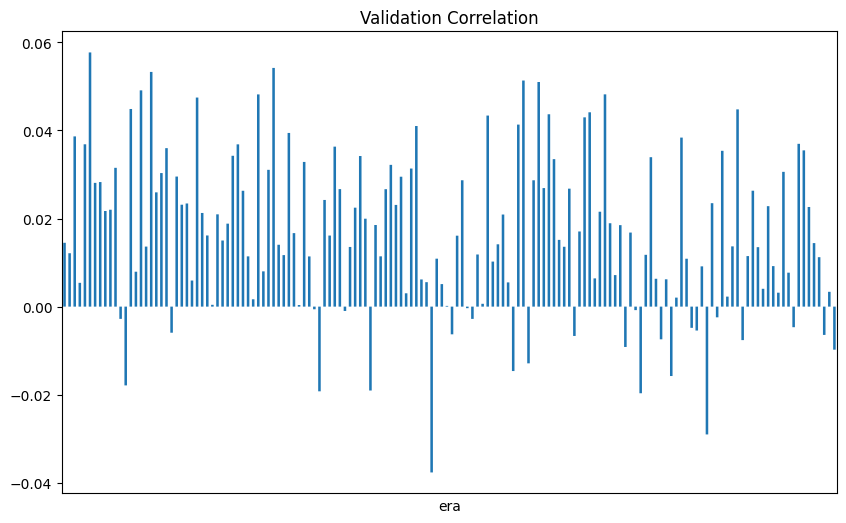

In [17]:
# Calcula la correlación por era entre nuestras predicciones y los valores "target".
per_era_corr = validation.groupby("era").apply(lambda x: practica_corr(x["prediction"], x["target"]))

# Gráfica de correlación por "era" 
per_era_corr.plot(kind="bar", title="Validation Correlation", figsize=(10, 6), xticks=[], snap=False);

En lugar de observar la puntuación "corr" de cada "era", resulta útil observar la puntuación "corr" acumulativa.

Esto se denomina "backtesting" en finanzas cuantitativas, donde las personas simulan el desempeño histórico de sus estrategias de inversión, puede considerar este gráfico como una prueba retrospectiva del desempeño de tu modelo durante el período de validación histórica.

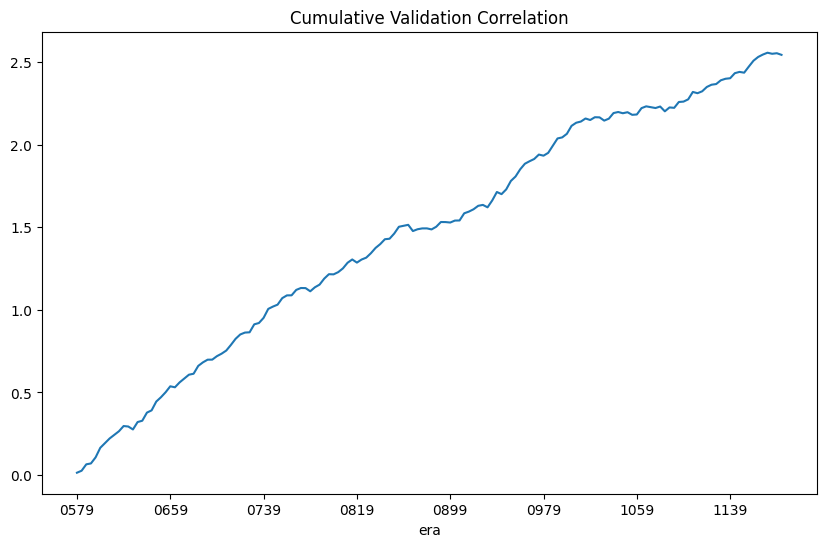

In [18]:
# Gráfica de la correlación acumulada por "era"
per_era_corr.cumsum().plot(kind="line", title="Cumulative Validation Correlation", figsize=(10, 6));

Métricas de rendimiento:
    
Para evaluar el rendimiento de nuestro modelo, también es útil calcular algunas métricas resumidas durante todo el período de validación.

La media de correlaciones es la medida principal del rendimiento de su modelo.

Sharpe es una medida de la coherencia de tu modelo, un concepto tomado de las finanzas, donde generalmente se refiere a los rendimientos ajustados al riesgo de una estrategia de inversión. Aquí calcularemos Sharpe como la correlación promedio dividida por la desviación estándar de las correlaciones.

La reducción máxima (max_drawdown) es una medida del riesgo de tu modelo, otro concepto tomado de las finanzas, donde generalmente se refiere a la pérdida financiera máxima sufrida por una estrategia de inversión. Aquí calcularemos la reducción máxima como la caída máxima desde el pico hasta el mínimo en la correlación de validación acumulativa.

In [19]:
# Calcula métricas de rendimiento
corr_mean = per_era_corr.mean()
corr_std = per_era_corr.std(ddof=0)
corr_sharpe = corr_mean / corr_std
max_drawdown = (per_era_corr.cumsum().expanding(min_periods=1).max() - per_era_corr.cumsum()).max()

base_result = pd.DataFrame({
    "mean": corr_mean,
    "std": corr_std,
    "sharpe": corr_sharpe,
    "max_drawdown": max_drawdown
}, index=["Value"]).T

base_result

,Value
mean,0.016729
std,0.018347
sharpe,0.911775
max_drawdown,0.037656


Estas metricas del modelo base son las que usare para comparar con otros modelos.

Estas métricas de rendimiento anteriores no son sorprendentes, pero son lo suficientemente buenas como para comenzar!

## Extraccion de caracteristicas

In [20]:
# Se obtienen las importancias de las caracteristicas del modelo base
f_importances = model.feature_importances_

# Se crea un dataframe ordenado con las importancias de las caracteristicas
model_importances = pd.DataFrame({
    "feature": feature_set,
    "importance": f_importances
}).sort_values(by="importance", ascending=False)

# Muestro las 10 caracteristicas mas importantes y las 10 menos importantes
print("Top 10 most important features:")
print(model_importances.head(10))
print("\n10 least important features:")
print(model_importances.tail(10))

Top 10 most important features:
                                      feature  importance
14         feature_jacobinical_symmetric_roll        3458
10         feature_geminate_crummiest_scourer        3329
34   feature_unanalyzable_excusable_whirlwind        3266
30          feature_toltec_korean_disfavourer        3213
22          feature_pottier_unmanly_collyrium        3149
2           feature_bridal_fingered_pensioner        3033
6   feature_departmental_inimitable_sentencer        2919
18        feature_maledictive_latter_psellism        2901
38         feature_unmodish_zymogenic_rousing        2889
26          feature_snakiest_somalian_wavelet        2721

10 least important features:
                                         feature  importance
29              feature_stretchy_spiniest_fizgig         611
19          feature_mendelian_undiscording_avion         607
35  feature_unbreakable_constraining_hegelianism         593
5                  feature_crosscut_whilom_ataxy        

<Figure size 1000x1200 with 0 Axes>

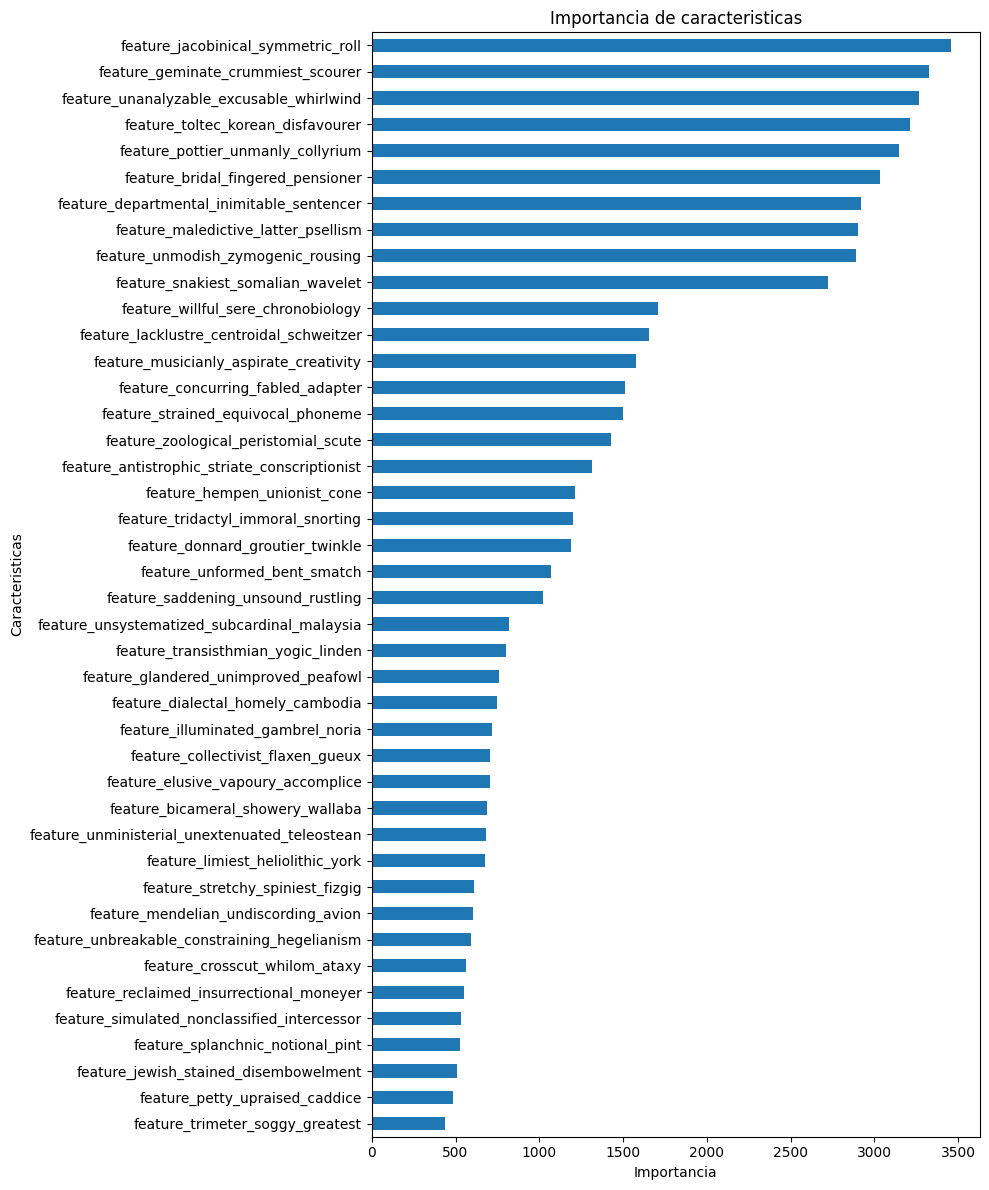

In [21]:
# Grafica de barras que muestra de forma visual la importancia de cada caracteristica
plt.figure(figsize=(10, 12)) 

# Usamos barh (barras horizontales) y ordenamos de menor a mayor
model_importances.sort_values(by="importance", ascending=True).plot(
    kind="barh", 
    x="feature", 
    y="importance", 
    figsize=(10, 12), 
    legend=False,
    title="Importancia de caracteristicas"
)
plt.xlabel("Importancia")
plt.ylabel("Caracteristicas")
plt.tight_layout() 
plt.show()

In [22]:
# Obtengo las 10 caracteristicas menos importantes para su eliminacion
least_important_features = model_importances.tail(10)["feature"].tolist()

# Muestro cuales son las caracteristicas que voy a eliminar
print("Features to drop: ")
print(least_important_features)

Features to drop: 
['feature_stretchy_spiniest_fizgig', 'feature_mendelian_undiscording_avion', 'feature_unbreakable_constraining_hegelianism', 'feature_crosscut_whilom_ataxy', 'feature_reclaimed_insurrectional_moneyer', 'feature_simulated_nonclassified_intercessor', 'feature_splanchnic_notional_pint', 'feature_jewish_stained_disembowelment', 'feature_petty_upraised_caddice', 'feature_trimeter_soggy_greatest']


Decidi eliminar las 10 caracteristicas menos importantes para no eliminar demasiadas caracteristicas, en un principio pense en eliminar las caracteristicas que no alcanzasen un umbral, por ejemplo, 1000, pero vi que si hacia eso, estaria eliminando 20 caracteristicas, casi la mitad del total, por lo que para intentar encontrar un equilibrio, decidi eliminar unicamente las 10 ultimas, reduciendo en un ~25% el numero de caracteristicas, manteniendo un gran porcentaje, ademas de que al ser las 10 menos importantes, su eliminacion tendria un posible efecto negativo menor.

In [23]:
# Creo una lista que contenga las caracteristicas restantes al eliminar las 10 menos importantes
red_feature_set = [
    feature for feature in feature_set if feature not in least_important_features
]

print("Reduced feature set length: ", len(red_feature_set))

Reduced feature set length:  32


In [24]:
# Entreno el mismo modelo base, pero esta vez uso el conjunto de datos con caracteristicas reducidas
red_model = lgb.LGBMRegressor(
  n_estimators=2000,
  learning_rate=0.01,
  max_depth=5,
  num_leaves=2**5-1,
  colsample_bytree=0.1,
  random_state=42,
  n_jobs=-1
)

red_model.fit(
  train[red_feature_set], # Aqui se seleccionan solo las caracteristicas restantes
  train["target"]
);

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001921 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 160
[LightGBM] [Info] Number of data points in the train set: 688184, number of used features: 32
[LightGBM] [Info] Start training from score 0.500008
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [25]:
# Genero las predicciones con este nuevo modelo
validation["prediction_red"] = red_model.predict(validation[red_feature_set]) # Aqui tambien se usan las caracteristicas restantes
validation[["era", "prediction_red", "target"]]

,era,prediction_red,target
id,,,
n000c290e4364875,0579,0.495974,0.50
n002a15bc5575bbb,0579,0.515403,0.25
n00309caaa0f955e,0579,0.509312,0.75
n0039cbdcf835708,0579,0.509459,0.50
n004143458984f89,0579,0.487431,0.50
...,...,...,...
nffc45fef92f9990,1183,0.505403,0.50
nffcd993886ef112,1183,0.491912,0.25
nffd2f8483ddb3cc,1183,0.501404,0.25


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2837480508.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_red = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_red"], x["target"]))


,Value
mean,0.014684
std,0.017873
sharpe,0.821586
max_drawdown,0.044782


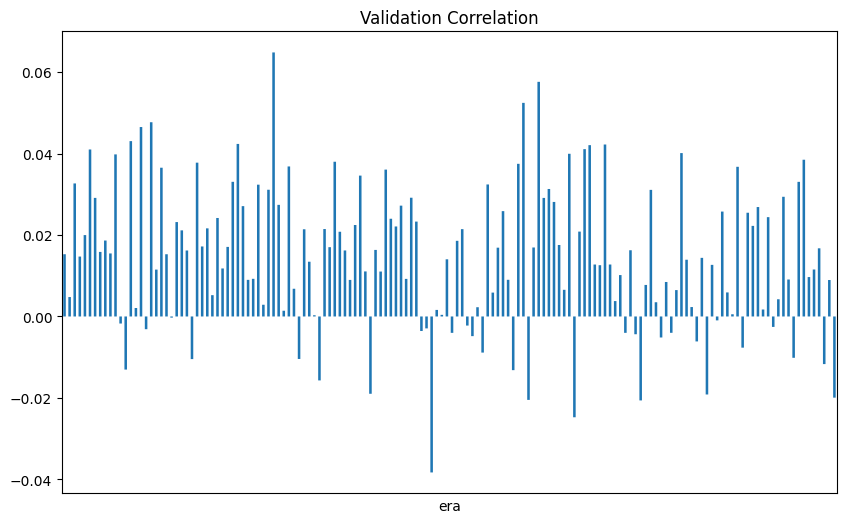

In [26]:
# Calculo la correlacion por era para este nuevo modelo
per_era_corr_red = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_red"], x["target"]))

# Grafica de barras para ver visualmente la correlacion por era
per_era_corr_red.plot(kind="bar", title="Validation Correlation", figsize=(10, 6), xticks=[], snap=False);

# Mas adelante se mostrara la grafica de la correlacion acumulada para este modelo junto a los resultados de los demas modelos

# Calculo de las metricas de rendimiento para este nuevo modelo
corr_mean_red = per_era_corr_red.mean()
corr_std_red = per_era_corr_red.std(ddof=0)
corr_sharpe_red = corr_mean_red / corr_std_red
max_drawdown_red = (per_era_corr_red.cumsum().expanding(min_periods=1).max() - per_era_corr_red.cumsum()).max()

# Dataframe que guarda los resultados del modelo
red_results = pd.DataFrame({
    "mean": corr_mean_red,
    "std": corr_std_red,
    "sharpe": corr_sharpe_red,
    "max_drawdown": max_drawdown_red
}, index=["Value"]).T

red_results

Resultado de la eliminacion de caracteristicas:

He obtenido las feature_importances usando el modelo base que se me proporciono, y obtuve las 10 features menos importantes, decidi eliminar estas 10 features y entrene un nuevo modelo usando los datos sin incluir estas 10 features, es decir, con un total de 32 en comparacion a las 42 features que habian. Tras este experimento, he descubierto que la preciosion del modelo no mejora, si no que ha empeorado, el sharpe bajo del ~0.91 a ~0.82, y el mean tambien bajo, de ~0.016 a ~0.014, pero tambien es cierto que el std bajo de ~0.018 a ~0.017, lo que significa que el modelo es menos volatil, pero el max_drawdonw ha empeorado, de ~0.03 a ~0.04, siendo este modelo mas riesgoso. Con esto puedo concluir que, en este problema, incluso las features menos importantes aportan valor.

## PCA

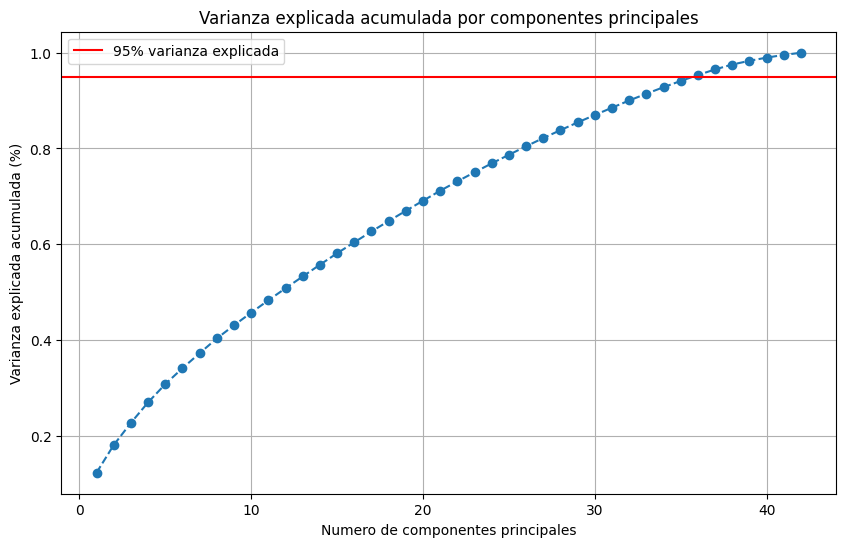

In [27]:
from sklearn.decomposition import PCA
import numpy as np

# Vamos a aplicar PCA
pca = PCA()

# Hacemos fit del PCA sobre train, pero con todas sus caracteristicas, ya que queremos ver la varianza explicada por todas ellas
pca.fit(train[feature_set])

# Calculo la varianza explicada acumulada
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Grafica que muestra la varianza explicada acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", linestyle="--")
plt.title("Varianza explicada acumulada por componentes principales")
plt.xlabel("Numero de componentes principales") # Este es el numero de componentes principales
plt.ylabel("Varianza explicada acumulada (%)") # Y esto es el porcentaje de varianza explicada acumulada
plt.grid(True)
plt.axhline(y=0.95, color="r", linestyle="-", label="95% varianza explicada") # Esta linea horizontal indica el 95% de varianza explicada, para ver cuantos componentes se necesitan para alcanzar este umbral
plt.legend(loc="best")
plt.show()

In [28]:
# Obtengo el numero de componentes necesarios para explicar el 95% de la varianza
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

# Muestro cual es ese numero
print(f"Number of components for 95% variance: {n_components_95}")

Number of components for 95% variance: 36


In [29]:
# Aplico PCA con ese numero de componentes
pca_95 = PCA(n_components=n_components_95)

# Se aplica sobre train y validation
pca_train = pca_95.fit_transform(train[feature_set])
pca_validation = pca_95.transform(validation[feature_set])


In [30]:
# De nuevo entreno el mismo modelo base, pero esta vez uso los datos transformados por PCA
pca_model = lgb.LGBMRegressor(
  n_estimators=2000,
  learning_rate=0.01,
  max_depth=5,
  num_leaves=2**5-1,
  colsample_bytree=0.1,
  random_state=42,
  n_jobs=-1
)

pca_model.fit(
  pca_train,
  train["target"]
);

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001532 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9180
[LightGBM] [Info] Number of data points in the train set: 688184, number of used features: 36
[LightGBM] [Info] Start training from score 0.500008
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

In [31]:
# Genero las predicciones del modelo
validation["prediction_pca"] = pca_model.predict(pca_validation)
validation[["era", "prediction_pca", "target"]]

d:\IMMUNE\env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,era,prediction_pca,target
id,,,
n000c290e4364875,0579,0.492691,0.50
n002a15bc5575bbb,0579,0.504123,0.25
n00309caaa0f955e,0579,0.523172,0.75
n0039cbdcf835708,0579,0.506402,0.50
n004143458984f89,0579,0.504249,0.50
...,...,...,...
nffc45fef92f9990,1183,0.499627,0.50
nffcd993886ef112,1183,0.491926,0.25
nffd2f8483ddb3cc,1183,0.518673,0.25


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\1662932308.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_pca = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_pca"], x["target"]))


,Value
mean,0.012362
std,0.016607
sharpe,0.744395
max_drawdown,0.031735


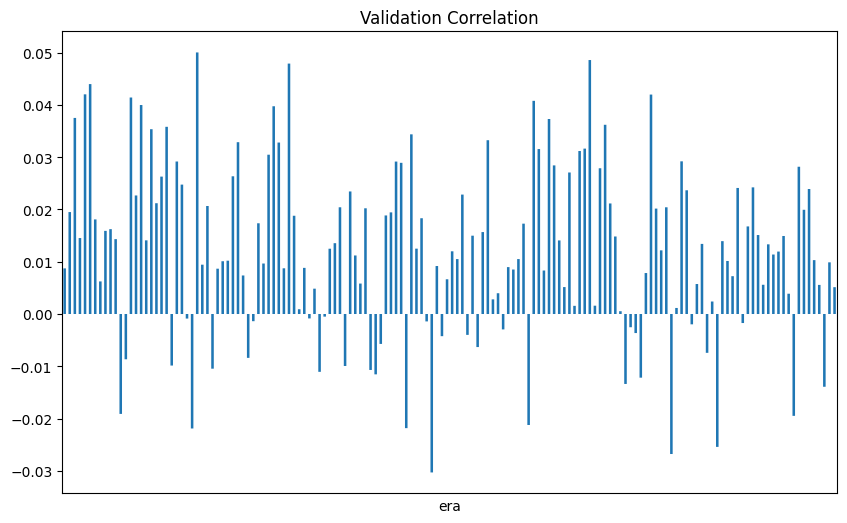

In [32]:
# Y aqui vuelvo a obtener la correlacion por era y las metricas de este modelo, ademas de la grafica de barras de la correlacion por era
per_era_corr_pca = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_pca"], x["target"]))

per_era_corr_pca.plot(kind="bar", title="Validation Correlation", figsize=(10, 6), xticks=[], snap=False);

# Al igual que con el modelo anterior, mostrare en una grafica la correlacion acumulada por era junto a la de los demas modelos mas adelante

corr_mean_pca = per_era_corr_pca.mean()
corr_std_pca = per_era_corr_pca.std(ddof=0)
corr_sharpe_pca = corr_mean_pca / corr_std_pca
max_drawdown_pca = (per_era_corr_pca.cumsum().expanding(min_periods=1).max() - per_era_corr_pca.cumsum()).max()

pca_results = pd.DataFrame({
    "mean": corr_mean_pca,
    "std": corr_std_pca,
    "sharpe": corr_sharpe_pca,
    "max_drawdown": max_drawdown_pca
}, index=["Value"]).T

pca_results

Resultados de aplicar PCA:

Tras aplicar PCA, el numero resultante de componentes es 36, este numero se obtuvo usando la varianza explicada acumulada, estableciendo un umbral del 95%, es decir, se busco el numero minimo necesario de componentes para capturar el 95% de la varianza total que estaba en las 42 features originales, esto se hizo ya que el objetivo de aplicar PCA es reducir la dimensionalidad(y con ello el ruido) retiendo la mayor cantidad de informacion posible. Este metodo permite un equilibrio entre eliminar ruido (5% de la varianza) y conservar la gran mayoria de la informacion de los datos.

Se observa tambien que el modelo entrenado con los datos a los que se aplico PCA obtuvo un peor rendimiento, con un sharpe de ~0.74 y un mean de ~0.012, aunque tambien es cierto que el std de este modelo es mejor que el de los modelos base y con seleccion de caracteristicas, por lo que es el mas consistente, en cuanto al max_drawdown, este modelo ha tenido uno parecido al del modelo base, ~0.03, por lo que son mas o menos iguales de riesgosos.

## Algunas graficas interesantes

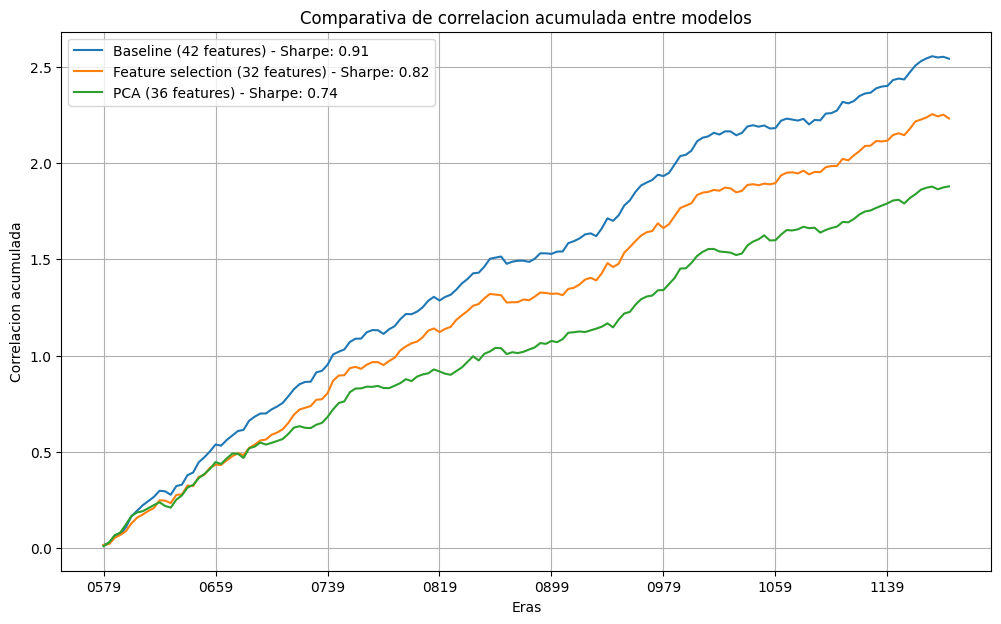

In [33]:
# Esta grafica muestra la correlacion acumulada de los tres modelos
plt.figure(figsize=(12, 7))

per_era_corr.cumsum().plot(label="Baseline (42 features) - Sharpe: 0.91", legend=True)
per_era_corr_red.cumsum().plot(label="Feature selection (32 features) - Sharpe: 0.82", legend=True)
per_era_corr_pca.cumsum().plot(label="PCA (36 features) - Sharpe: 0.74", legend=True)

plt.title("Comparativa de correlacion acumulada entre modelos")
plt.xlabel("Eras")
plt.ylabel("Correlacion acumulada")
plt.grid(True)
plt.show()

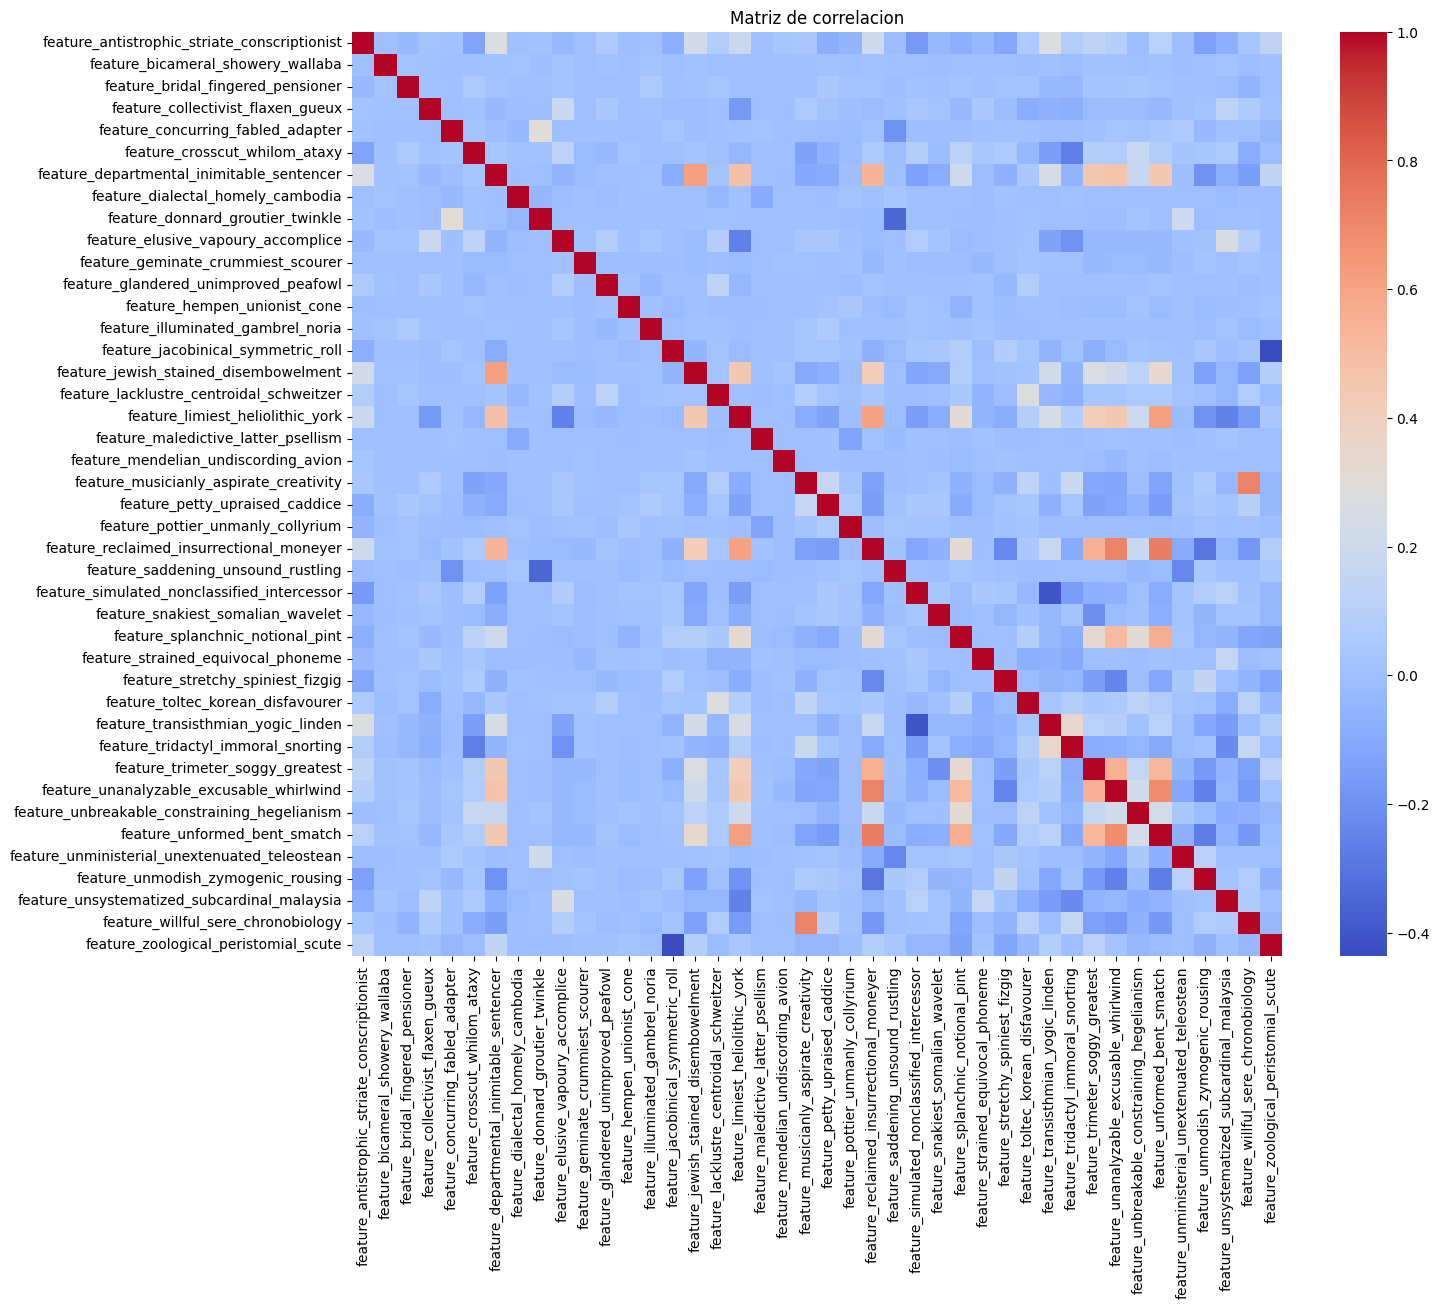

In [34]:
import seaborn as sns

# Matriz de correlacion de las caracteristicas originales
corr_matrix = train[feature_set].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(
    corr_matrix, 
    cmap="coolwarm", # Un color azul indica correlacion negativa y un rojo correlacion positiva
    annot=False
)

plt.title("Matriz de correlacion")
plt.show()

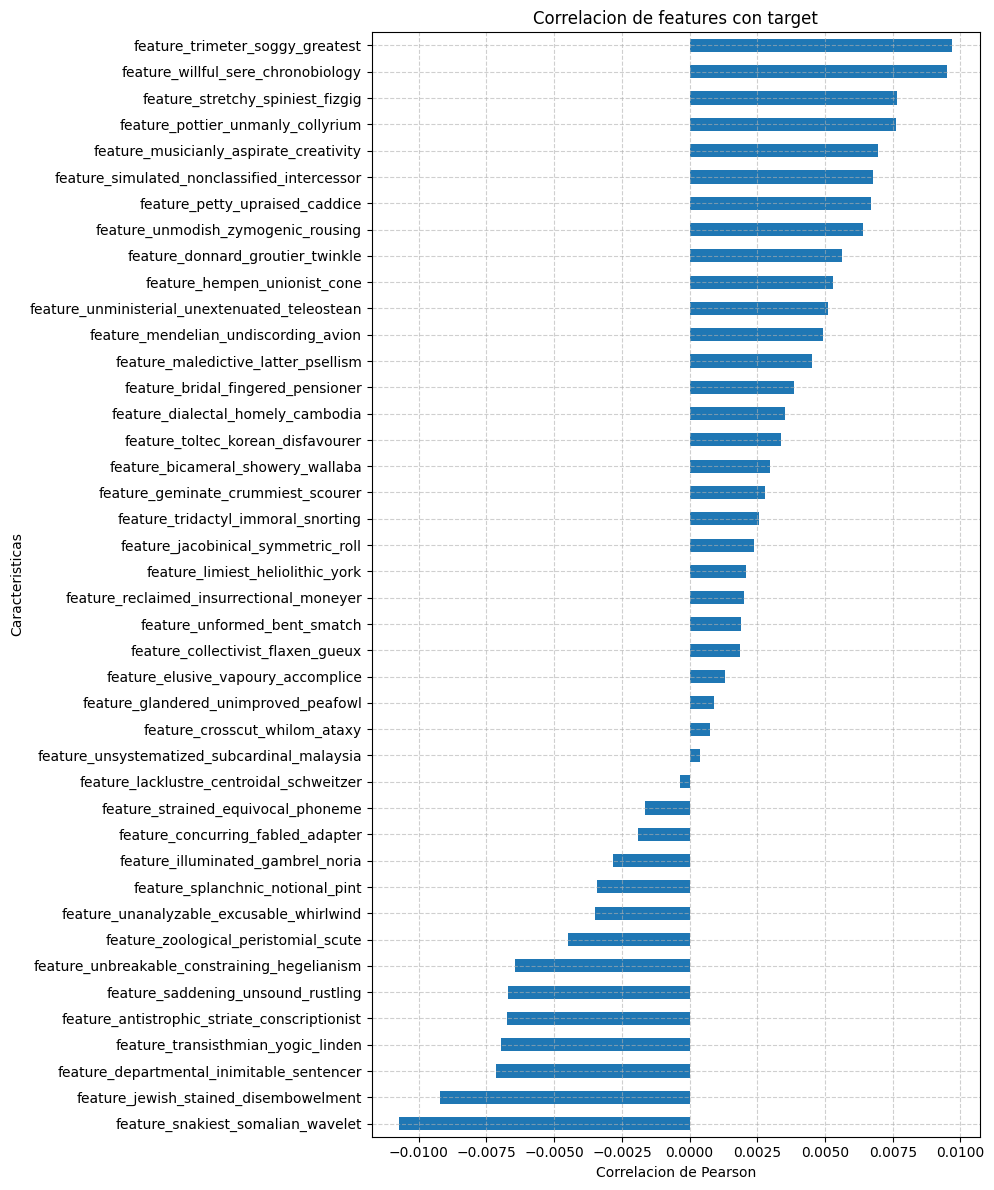

In [35]:
# Grafica que muestra la correlacion de cada caracteristica con target

# Calculo la matriz de correlacion entre todas las caracteristicas y target
corr_matrix_with_target = train[feature_set + ["target"]].corr()

# Seleccionp solo la columna 'target' de esa matriz
correlations_with_target = corr_matrix_with_target["target"]

# Elimina la fila 'target' 
correlations_with_target = correlations_with_target.drop("target")

# Ordeno los valores para que el grafico este ordenado
correlations_with_target_sorted = correlations_with_target.sort_values(ascending=True)

# Configuro la grafica
plt.figure(figsize=(10, 12)) 
correlations_with_target_sorted.plot(
    kind="barh",
    figsize=(10, 12),
    title="Correlacion de features con target"
)

plt.xlabel("Correlacion de Pearson")
plt.ylabel("Caracteristicas")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

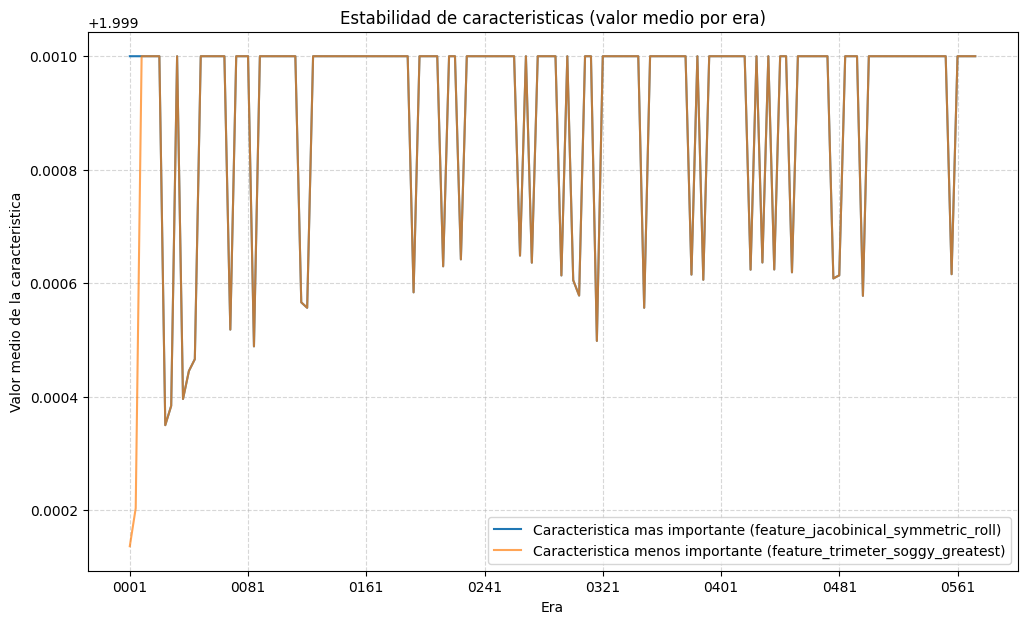

In [36]:
# Cojo la caracteristica mas importante y la menos importante
feature_importante = model_importances.iloc[0]['feature']  # La primera de la lista de importancias
feature_debil = model_importances.iloc[-1]['feature'] # La ultima de la lista

# Agrupo por 'era' y calcula la media de esas caracteristicas
mean_feature_importante = train.groupby('era')[feature_importante].mean()
mean_feature_debil = train.groupby('era')[feature_debil].mean()

# Grafica que muestra la estabilidad de las dos caracteristicas a lo largo del tiempo
plt.figure(figsize=(12, 7))
mean_feature_importante.plot(label=f"Caracteristica mas importante ({feature_importante})", legend=True)
mean_feature_debil.plot(label=f"Caracteristica menos importante ({feature_debil})", legend=True, alpha=0.7)

plt.title("Estabilidad de caracteristicas (valor medio por era)")
plt.xlabel("Era")
plt.ylabel("Valor medio de la caracteristica")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Con la grafica de arriba se comprueba que, efectivamente, la relacion entre las caracteristicas y los rendimientos es no estacionaria, como se ve en la grafica, las lineas no son "llanas", si no que tienen saltos muy bruscos, por lo que se puede deducir que el feature-risk proviene de la inestabilidad de las propias "features".   

## Modeling

Antes de seguir, quiero explicar por que no dividi train en subconjuntos de entrenamiento y test, esto es por una simple razon, los datos son una serie temporal ordenada por eras. Si hubiera dividido esos datos aleatoriamente, estaria mezclando distintos tiempos, distintas eras, lo que provocaria una "fuga de datos" y las resultados que obtendria no serian realistas. Para evitar esto, decidi entrenar el modelo con todo el conjunto de train (el "pasado") y evaluarlo con validation (el "futuro"), que es un conjunto de datos completamente separado y posterior en el tiempo. Otra razon es que, no lo veo necesario ya que tengo validation, que esta completamente separado de train, sirviendo como un conjunto de "futuro" mucho mas robusto.

Como antes use LGBM, para el algoritmo que hemos dado en clase, he escogido el RandomForestRegressor.

Las razones son las siguientes:

1. Este es un problema de regresion, por lo que este algoritmo es adecuado
2. LGBM es un modelo de Boosting(construye los arboles secuencialmente y corrige los errores del anterior) y RandomForestRegressor es uno de Bagging(construye los arboles en paralelo y promedia el resultado). Esto da una comparacion interesante, enfrentando dos formas opuestas para intentar solucionar el mismo problema.
3. Robustez, RandomForestRegressor es robusto, por lo que no es necsario aplicar tecnicas como el PCA ya que no se ve afectado por la escala de los datos, ademas de que es bueno capturando relaciones no lineales.

In [ ]:
# Entreno el random forest con todos sus hiperparametros por defecto, excepto el max_depth, que es el mismo que el de LBGM base, para poder hacer una comparacion justa
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    train[feature_set],
    train["target"]
)

,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [38]:
# Genero las predicciones
validation["prediction_rf"] = rf_model.predict(validation[feature_set])
validation[["era", "prediction_rf", "target"]]

,era,prediction_rf,target
id,,,
n000c290e4364875,0579,0.495628,0.50
n002a15bc5575bbb,0579,0.504987,0.25
n00309caaa0f955e,0579,0.500956,0.75
n0039cbdcf835708,0579,0.509337,0.50
n004143458984f89,0579,0.493178,0.50
...,...,...,...
nffc45fef92f9990,1183,0.499711,0.50
nffcd993886ef112,1183,0.492294,0.25
nffd2f8483ddb3cc,1183,0.507216,0.25


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\615448122.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_rf = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_rf"], x["target"]))


,Value
mean,0.013395
std,0.018234
sharpe,0.734589
max_drawdown,0.058212


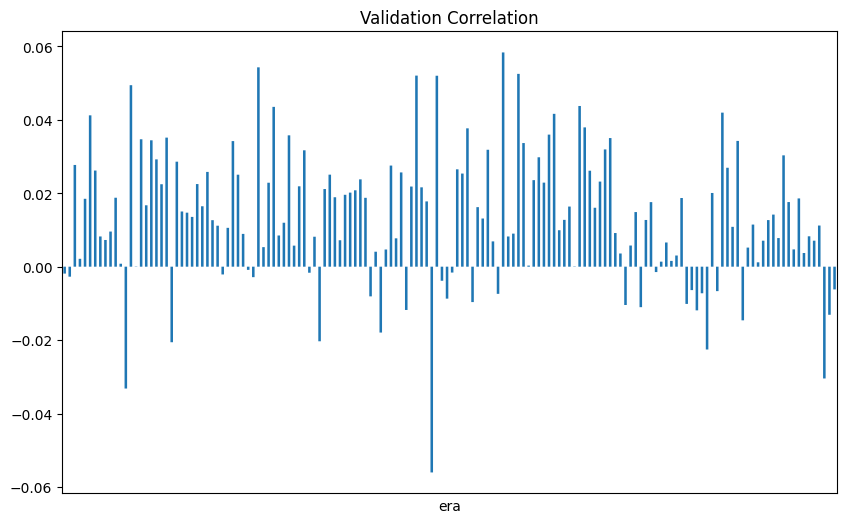

In [39]:
# Calculo la correlacion por era para este nuevo modelo
per_era_corr_rf = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_rf"], x["target"]))

# Grafica de barras para ver visualmente la correlacion por era
per_era_corr_rf.plot(kind="bar", title="Validation Correlation", figsize=(10, 6), xticks=[], snap=False);

# Calculo de las metricas de rendimiento para este nuevo modelo
corr_mean_rf = per_era_corr_rf.mean()
corr_std_rf = per_era_corr_rf.std(ddof=0)
corr_sharpe_rf = corr_mean_rf / corr_std_rf
max_drawdown_rf = (per_era_corr_rf.cumsum().expanding(min_periods=1).max() - per_era_corr_rf.cumsum()).max()

# Dataframe que guarda los resultados del modelo
rf_results = pd.DataFrame({
    "mean": corr_mean_rf,
    "std": corr_std_rf,
    "sharpe": corr_sharpe_rf,
    "max_drawdown": max_drawdown_rf
}, index=["Value"]).T

rf_results

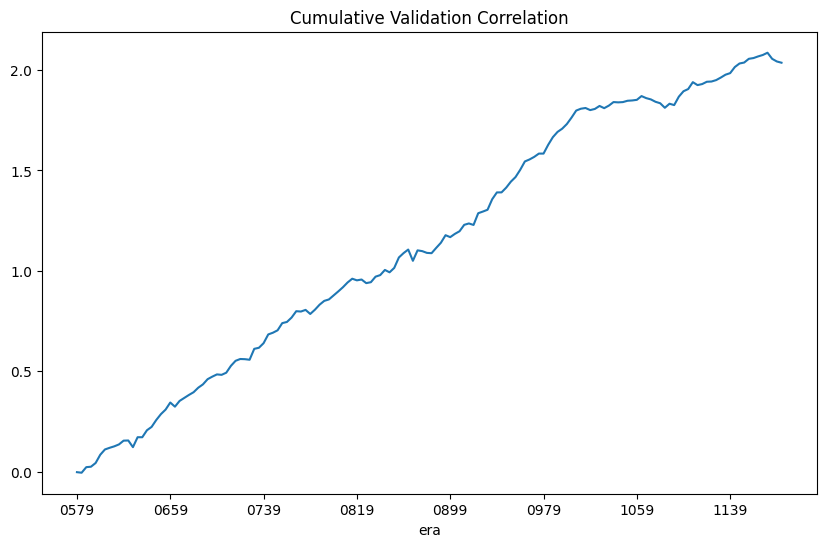

In [40]:
# Grafica que muestra la correlacion acumulada del random forest
per_era_corr_rf.cumsum().plot(kind="line", title="Cumulative Validation Correlation", figsize=(10, 6));

Conclusiones:

Al comparar los dos modelos de arbol, el LGBM (modelo base) fue mejor que el RandomForestRegressor. Usando la misma complejidad de arbol (max_depth=5) y con sus hiperparametros por defecto, el base (un modelo de Boosting), obtuvo un sharpe de ~0.91, mientras que el RandomForest (un modelo de Bagging) solo consiguio un sharpe de ~0.73, un riesgo (max_drawdown) mucho mayor, un std muy parecido y un peor mean. Esto demuestra que la estrategia de Boosting (aprender secuencialmente de los errores) es mucho mas efectiva para este problema que la de Bagging (promediar árboles independientes).

Que es el overfitting y como evitarlo:

El overfitting o sobreajuste es un problema que ocurre cuando un modelo se vuelve muy complejo y memoriza los datos con los que se entreno, capturando tanto el patron especifico de los datos, como tambien el "ruido" de esos datos, en vez del patron general. Esto provoca que el modelo funcione perfectamente en los datos de entrenamiento que ya ha visto, pero que sea incapaz de generalizar, fallando cuando se le presentan datos nuevos y desconocidos (como los de validacion). Esto puede ocurrir por varios motivos, como datos ruidosos, datos incorrectamente etiquetados, presencia de outliers, pocos datos de entrenamiento, atributos irrelevantes o demasiadas caracteristicas de entrada, haciendo que la funcion hipotesis se adapte demasiado a los datos de entrenamiento.

Para evitar el overfitting, se pueden aplicar varias tecnicas como usar mas datos de entrenamiento, aplicar regularizacion mediante penalizaciones, emplear validacion cruzada para evaluar mejor la capacidad de generalizacion del modelo, reduccion de caracteristicas de entrada con tecnicas como seleccion de caracteristicas o PCA.

Siendo un poco mas concretos, en este trabajo se aplico preprocesamiento para la reduccion de ruido, como tambien limitando la complejidad de los modelos de arbol con max_depth=5.


## Validation

Evalue los resultados de cada modelo usando practica_corr, una correlacion de Pearson modificada, calculada para cada "era" y luego agregada en metricas como la media, la desviacion estandar y el ratio de Sharpe. La razon por la que se usa la correlacion y no F1-score es la naturaleza del problema, no es un problema de clasificacion, sino de regresion. El F1-score se usa para medir la precision de un modelo que predice categorias discretas (ej. spam o no spam), mientras que target es un valor numerico (de 0 a 1). Por lo tanto, necesitamos una metrica de regresion como la correlacion, que mide la fuerza y la direccion de la relacion entre nuestras predicciones y el target, siendo un buen indicador del rendimiento de una accion.

Los resultados se muestran tanto cuantitativa como graficamente en los modelos correspondientes junto a la explicacion de sus metricas de rendimiento.

# Optimizaciones

He decidido usar Ridge Regression como metodo de mejora, por varias razones, la primera es que en el enunciado lo mencionaba explicitamente como una de las opciones para esta tarea, como una alternativa a Feature Neutralization. Feature Neutralization es una tecnica bastante compleja de post procesamiento que busca reducir el feature risk, neutralizando las predicciones, es decir, eliminando su correlacion con features de riesgo especificas, esto es bastante complejo ya que habria requerido implementar una funcion desde cero para cada era, ejecutando una regresion para limpiar las predicciones de su correlacion con ciertas features de riesgo, el problema tambien recae en estas features de riesgo, contra cuales se deberia de neutralizar, las 10 mas importantes, todas, etc.

En cambio, la alternativa, Ridge Regression, como se dice en el pdf, funciona bien cuando hay muchas caracteristicas ligeramente utiles en la prediccion, cosa que ya comprobe cuando hice anteriormente feature selection, ya que al eliminar las 10 menos importantes, el rendimiento emperoro. Ademas de esto, es bastante mas sencillo de usar, ya que es un modelo ya implementado en sklearn y simplemente necesitaria importarlo y entrenarlo. 

Entrando a como funciona Ridge Regression, este es un modelo que al igual que la regresion lineal, intenta encontrar una relacion entre las caracteristicas y el target. El truco de Ridge es que penaliza el dar mucha importancia a cualquier caracteristica, haciendo que le de pesos comparables y pequeños a cada caracteristica.

In [ ]:
# Importo Ridge y creo un pipeline que incluya estandarizacion y el modelo
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Incluyo estandarizacion ya que Ridge es sensible a la escala de las caracteristicas
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge_model", Ridge(random_state=42))
])

In [ ]:
# Hago fit del pipeline
pipeline.fit(train[feature_set], train["target"])

,steps,"[('scaler', ...), ('ridge_model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None


In [ ]:
# Genero las predicciones del modelo
validation["prediction_ridge"] = pipeline.predict(validation[feature_set])
validation[["era", "prediction_ridge", "target"]]

,era,prediction_ridge,target
id,,,
n000c290e4364875,0579,0.495328,0.50
n002a15bc5575bbb,0579,0.512769,0.25
n00309caaa0f955e,0579,0.509868,0.75
n0039cbdcf835708,0579,0.503620,0.50
n004143458984f89,0579,0.483945,0.50
...,...,...,...
nffc45fef92f9990,1183,0.500684,0.50
nffcd993886ef112,1183,0.480833,0.25
nffd2f8483ddb3cc,1183,0.514096,0.25


C:\Users\ASUS\AppData\Local\Temp\ipykernel_135288\2291413465.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_ridge = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_ridge"], x["target"]))


,Value
mean,0.012509
std,0.017786
sharpe,0.703324
max_drawdown,0.058605


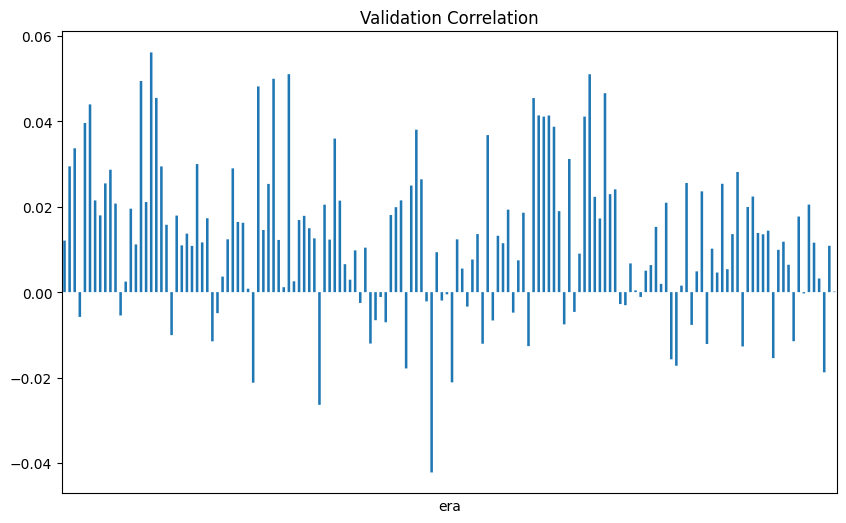

In [ ]:
# Vuelvo a obtener la correlacion por era y las metricas de este modelo, ademas de la grafica de barras de la correlacion por era
per_era_corr_ridge = validation.groupby("era").apply(lambda x: practica_corr(x["prediction_ridge"], x["target"]))

per_era_corr_ridge.plot(kind="bar", title="Validation Correlation", figsize=(10, 6), xticks=[], snap=False);

# Calculo de las metricas de rendimiento para este nuevo modelo
corr_mean_ridge = per_era_corr_ridge.mean()
corr_std_ridge = per_era_corr_ridge.std(ddof=0)
corr_sharpe_ridge = corr_mean_ridge / corr_std_ridge
max_drawdown_ridge = (per_era_corr_ridge.cumsum().expanding(min_periods=1).max() - per_era_corr_ridge.cumsum()).max()

# Dataframe que guarda los resultados del modelo
ridge_results = pd.DataFrame({
    "mean": corr_mean_ridge,
    "std": corr_std_ridge,
    "sharpe": corr_sharpe_ridge,
    "max_drawdown": max_drawdown_ridge
}, index=["Value"]).T

ridge_results

Conclusiones:

El modelo base sigue siendo el mejor de todos, y este modelo de Ridge Regression ha sido el peor con un sharpe de ~0.7 y mean de ~0.012, un gran riesgo con un max_drawdown de ~0.05, aunque en comparacion al modelo base, tiene una pequeña mejora de std, con ~0.017.

De esto puedo obtener una conclusion, la relacion entre las caracteristicas y target es altamente no lineal, esto debido a la gran diferencia entre el sharpe del modelo base y del de Ridge Regression, demostrando que el LGBM pudo encontrar patrones complejos y no lineales que el Ridge no pudo. 

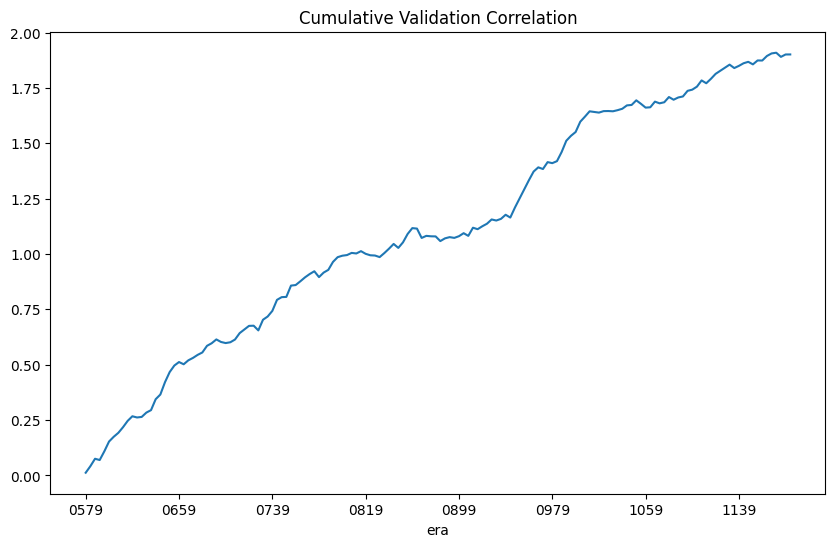

In [ ]:
# Grafica que muestra la correlacion acumulada del modelo Ridge
per_era_corr_ridge.cumsum().plot(kind="line", title="Cumulative Validation Correlation", figsize=(10, 6));

Ahora voy a hacer una busqueda de hiperparametros usando el modelo base porque es el que mejores resultados ha dado de todos los modelos. Para ello usare Grid Search para automatizar la busqueda, intentando encontrar una combinacion de hiperparametros que supere a la del modelo base

In [ ]:
# Divido las eras en 80% para entrenar y 20% para validar
all_eras = train["era"].unique()
split_index = int(len(all_eras) * 0.8)
# En este caso y para esta ocasion, si divido train en dos subconjuntos para no contaminar la evaluacion final usando validation

# Eras para el entrenamiento
internal_train_eras = all_eras[:split_index]
# Eras para la validacion
internal_validation_eras = all_eras[split_index:]

# Aplicamos el "embargo" de 4 eras
last_train_era = int(internal_train_eras[-1])
eras_to_embargo = [str(era).zfill(4) for era in [last_train_era + i for i in range(4)]]

# Filtramos las eras embargadas de nuestro set de validación 
internal_validation_eras = [era for era in internal_validation_eras if era not in eras_to_embargo]

# Creamos los df finales para la optimizacion
internal_train = train[train["era"].isin(internal_train_eras)]
internal_validation = train[train["era"].isin(internal_validation_eras)]

print(f"Eras totales en 'train': {len(all_eras)}")
print(f"Eras para optmizacion (train): {len(internal_train_eras)}")
print(f"Eras para optimizacion (validation): {len(internal_validation_eras)}")

Eras totales en 'train': 144
Eras para optmizacion (train): 115
Eras para optimizacion (validation): 29


In [ ]:
from sklearn.model_selection import ParameterGrid

# Defino el grid con las opciones de hiperparametros que quiero probar
param_grid_options = {
    'learning_rate': [0.01, 0.02],
    'num_leaves': [20, 31, 40],     
    'colsample_bytree': [0.1, 0.2, 0.3], 
    'n_estimators': [2000],
    "max_depth": [1, 3, 5] 
}

# Creo la lista de todas las combinaciones posibles
grid = ParameterGrid(param_grid_options)

In [ ]:
# Creo un diccionario para guardar los resultados de cada combinacion
grid_results = {}

# Itero sobre cada combinacion de hiperparametros
for i, params in enumerate(grid):
    
    # 1. Defino y entreno el modelo
    hpo_model = lgb.LGBMRegressor(**params, random_state=42, n_jobs=-1)
    
    hpo_model.fit(
        internal_train[feature_set],
        internal_train["target"]
    )
    
    # Predigo en el set de validacion interno
    internal_validation["prediction_hpo"] = hpo_model.predict(
        internal_validation[feature_set]
    )
    
    # Calculo la correlacion por era
    per_era_corr_hpo = internal_validation.groupby("era").apply(
        lambda x: practica_corr(x["prediction_hpo"], x["target"])
    )
    
    # Calculo las metricas 
    corr_mean_hpo = per_era_corr_hpo.mean()
    corr_std_hpo = per_era_corr_hpo.std(ddof=0)
    corr_sharpe_hpo = corr_mean_hpo / corr_std_hpo
    
    print(f"Sharpe: {corr_sharpe_hpo}")
    
    # Guardo los resultados junto a los hiperparametros usados
    grid_results[i] = {"sharpe": corr_sharpe_hpo, "params": params}

# Obtengo la mejor la mejor combinacion de hiperparametros
best_config_name = max(grid_results, key=lambda k: grid_results[k]["sharpe"])
best_params = grid_results[best_config_name]["params"]

print(f"Mejor combinacion encontrada: {best_config_name}")
print(f"Mejor sharpe (interno): {grid_results[best_config_name]["sharpe"]}")
print(f"Mejores hiperparametros: {best_params}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001524 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.717850
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001576 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.717850
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003815 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.717850
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003513 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.125805
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002436 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.125805
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001473 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.125805
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002041 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.023326
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002166 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.982851
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005387 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.972360
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.908752
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002365 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.908752
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003836 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.908752
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002033 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.069745
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002259 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.069745
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.069745
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.072586
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002109 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.003169
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004050 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.989629
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004182 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.568214
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003828 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.568214
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004046 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.568214
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006071 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.221357
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003288 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.221357
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003574 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.221357
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006317 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.116429
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004637 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.058561
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.042534
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004390 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.793950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004444 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.793950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004755 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.793950
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004362 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.141041
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.141041
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004198 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.141041
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004281 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.991839
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003285 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.821936
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004507 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.838031
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005605 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.529784
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005254 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.529784
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006743 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.529784
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005487 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.308057
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005405 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.308057
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005595 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.308057
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006438 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.070588
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005563 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.917638
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005501 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.965126
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006169 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.788747
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006395 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.788747
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006958 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.788747
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006682 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.101621
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005947 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.101621
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004776 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 2.101621
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007200 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.839190
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006582 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


Resultados: Sharpe = 1.658138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007975 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 539937, number of used features: 42
[LightGBM] [Info] Start training from score 0.500029
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  internal_validation["prediction_hpo"] = hpo_model.predict(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2742747914.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_hpo = internal_validation.groupby("era").apply(


In [50]:
# Defino el modelo final con los mejores hiperparametros encontrados
final_model = lgb.LGBMRegressor(**best_params, random_state=42, n_jobs=-1)

# Ahora entreno con todos los datos de train
final_model.fit(
    train[feature_set], 
    train["target"]
)

# Genero las predicciones en validation real
validation["prediction_final_optimized"] = final_model.predict(
    validation[feature_set]
)

# Calculo la correlacion por era para el modelo final optimizado
per_era_corr_final = validation.groupby("era").apply(
    lambda x: practica_corr(x["prediction_final_optimized"], x["target"])
)

# Calculo las metricas finales
final_mean = per_era_corr_final.mean()
final_std = per_era_corr_final.std(ddof=0)
final_sharpe = final_mean / final_std
final_max_dd = (per_era_corr_final.cumsum().expanding(min_periods=1).max() - per_era_corr_final.cumsum()).max()

# Dataframe que guarda los resultados del modelo final optimizado
final_results = pd.DataFrame({
    "mean": final_mean,
    "std": final_std,
    "sharpe": final_sharpe,
    "max_drawdown": final_max_dd
}, index=["Values"]).T

final_results

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007886 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 210
[LightGBM] [Info] Number of data points in the train set: 688184, number of used features: 42
[LightGBM] [Info] Start training from score 0.500008
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

C:\Users\ASUS\AppData\Local\Temp\ipykernel_132920\2489272894.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_era_corr_final = validation.groupby("era").apply(


,Values
mean,0.017023
std,0.018218
sharpe,0.934385
max_drawdown,0.045425


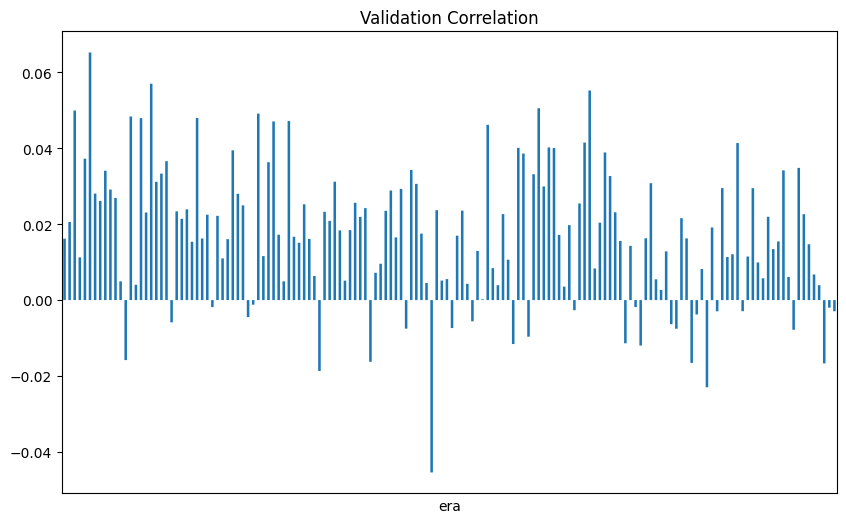

In [51]:
per_era_corr_final.plot(kind="bar", title="Validation Correlation", figsize=(10, 6), xticks=[], snap=False);

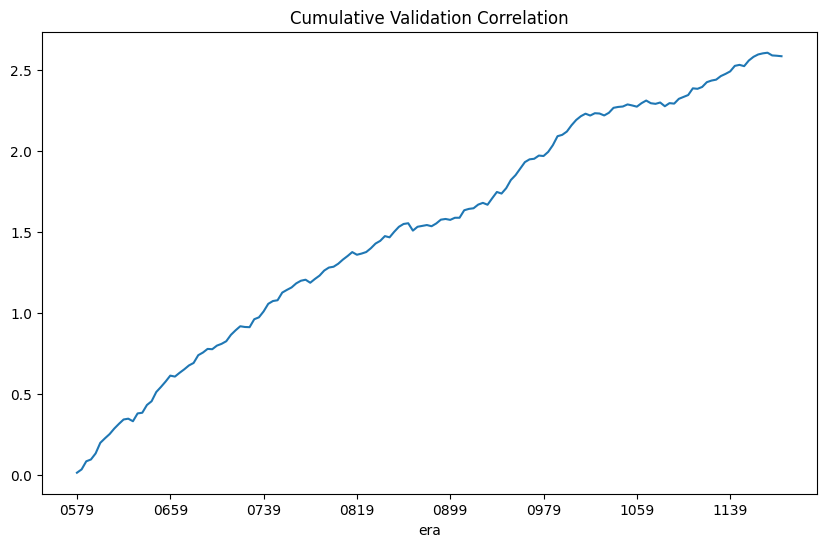

In [52]:
per_era_corr_final.cumsum().plot(kind="line", title="Cumulative Validation Correlation", figsize=(10, 6));

Conclusiones:

Este ultimo modelo con hiperparametros optimizados ha superado al anterior mejor modelo, el base, en casi todas las metricas, con un sharpe de ~0.93 en comparacion a ~0.91, un mean de ~0.017 vs ~0.016, un std de ~0.0182 vs ~0.0183. La unica metrica en la que sigue siendo mejor el modelo base es max_drawdown, con un ~0.04 vs ~0.03, pero la mejora en sharpe puede justificar esta diferencia entre el max_drawdown.

SUBMISSIONS

Vamos a evaluar los modelos según su rendimiento en vivo!

La tarea es generar predicciones sobre valores objetivo desconocidos, que representan los rendimientos del mercado de valores dentro de X días.

In [54]:
# Descargar las últimas entradas en tiempo real
napi.download_dataset(f"{DATA_VERSION}/live.parquet")

# Carga dichas características
live_features = pd.read_parquet(f"{DATA_VERSION}/live.parquet", columns=feature_set)

# Genera predicciones en vivo
live_predictions = final_model.predict(live_features[feature_set])

#Evaluar
live_predictions

# Envío
pd.Series(live_predictions, index=live_features.index).to_frame("prediction")

2025-11-04 01:51:03,281 INFO numerapi.utils: starting download
v5.0/live.parquet: 8.39MB [00:03, 2.33MB/s]                            


,prediction
id,
n001b5cc671480f8,0.484451
n001e484d6a60cde,0.502557
n002a862c140978e,0.498912
n0033096bae8eb9a,0.504390
n004ec27fa53f292,0.487760
...,...
nffd60ecda65f998,0.479491
nffde21be9bf1258,0.501074
nffdec906fde9863,0.487620


In [55]:
import cloudpickle

# Defino el nombre del fichero donde se guardara el modelo
model_filename = "final_model.pkl"

# Elijo el modelo a guardar, en este caso, final_model que es el que mejor rendimiento ha dado
model_to_save = final_model

# Guardo (serializo) el modelo en el disco
with open(model_filename, 'wb') as f:
    cloudpickle.dump(model_to_save, f)
print("Model saved")

Model saved
